In [1]:
# Importing everything we need

import os, json, pickle, random, time, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# Configuration of model run(s) and save it so we know which run yields which results
CONFIG = {
    "experiment_name": "slp_tfidf_extremism_v1",
    "random_seed": 30,

    "data_path": "/kaggle/input/datasets/anthony73/kaggle-environment-extremism-detection/extremism_dataset_final.csv",

    # Change these after checking df.columns
    "text_col": "Original_Message",
    "label_col": "Extremism_Label",

    "test_size": 0.2,
    "max_features": 20000,
    "ngram_range": (1, 2),
    "min_df": 2,
    "max_df": 0.95,

    "batch_size": 32,
    "epochs": 30,
    "lr": 0.01,
    "weight_decay": 0.0,
    "threshold": 0.5,

    # SHAP settings
    "shap_background_size": 100,
    "shap_explain_size": 200,
}

OUTPUT_DIR = Path("/kaggle/working") / CONFIG["experiment_name"]
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(CONFIG["random_seed"])

In [3]:
# Loading and inspecting our dataset
df = pd.read_csv(CONFIG["data_path"])

print(df.shape)
display(df.head())
print(df.columns)
print(df[CONFIG["label_col"]].value_counts(dropna=False))

(3000, 2)


,Original_Message,Extremism_Label
0,sixth forms should burn to the ground,EXTREMIST
1,whatever should burn benders to the ground,EXTREMIST
2,factories should burn to the ground,EXTREMIST
3,halal factories should burn to the ground,EXTREMIST
4,nhs should burn to the ground,EXTREMIST


Index(['Original_Message', 'Extremism_Label'], dtype='object')
Extremism_Label
NON_EXTREMIST    1603
EXTREMIST        1397
Name: count, dtype: int64


In [4]:
# Standard data cleanup protocol and pre-processing

def clean_text(text):
    text = str(text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df = df[[CONFIG["text_col"], CONFIG["label_col"]]].dropna()
df[CONFIG["text_col"]] = df[CONFIG["text_col"]].apply(clean_text)

# Ensure binary integer labels (EXTREMIST = 1, NON_EXTREMIST = 0)
# Only map if the column contains strings (to avoid re-run errors)
if df[CONFIG["label_col"]].dtype == object:
    label_conv_map = {"NON_EXTREMIST": 0, "EXTREMIST": 1}
    df[CONFIG["label_col"]] = df[CONFIG["label_col"]].map(label_conv_map)

if df[CONFIG["label_col"]].isna().any():
    raise ValueError("Unexpected label values found.")

X = df[CONFIG["text_col"]].values
y = df[CONFIG["label_col"]].values

print("Dataset size:", len(df))
print("Positive rate:", y.mean())

Dataset size: 2999
Positive rate: 0.4658219406468823


In [5]:
# Inspecting the data after processing
print(df.shape)
display(df.head())
print(df.columns)
print(df[CONFIG["label_col"]].value_counts(dropna=False))

(2999, 2)


,Original_Message,Extremism_Label
0,sixth forms should burn to the ground,1
1,whatever should burn benders to the ground,1
2,factories should burn to the ground,1
3,halal factories should burn to the ground,1
4,nhs should burn to the ground,1


Index(['Original_Message', 'Extremism_Label'], dtype='object')
Extremism_Label
0    1602
1    1397
Name: count, dtype: int64


In [6]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_seed"],
    stratify=y
)

print(len(X_train_text), len(X_test_text))

# Ensure stratification is functioning
print("Train positive rate:", y_train.mean())
print("Test positive rate:", y_test.mean())

2399 600
Train positive rate: 0.4660275114631096
Test positive rate: 0.465


In [7]:
# Vectorizing (TF-IDF) using the configuration settings
vectorizer = TfidfVectorizer(
    max_features=CONFIG["max_features"],
    ngram_range=CONFIG["ngram_range"],
    min_df=CONFIG["min_df"],
    max_df=CONFIG["max_df"],
    lowercase=True,
    stop_words="english"
)

X_train_vec = vectorizer.fit_transform(X_train_text)
X_test_vec = vectorizer.transform(X_test_text)

print(X_train_vec.shape)
print(X_test_vec.shape)

(2399, 4801)
(600, 4801)


In [8]:
# Conversion to PyTorch tensors
X_train_tensor = torch.tensor(X_train_vec.toarray(), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_vec.toarray(), dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True
)

In [9]:
# Defining our SLP model
class SLPTextClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        logits = self.linear(x)
        return logits

input_dim = X_train_tensor.shape[1]
model = SLPTextClassifier(input_dim)
print(model)

SLPTextClassifier(
  (linear): Linear(in_features=4801, out_features=1, bias=True)
)


In [10]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"]
)

history = []

best_f1 = 0
for epoch in range(CONFIG["epochs"]):
    model.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        logits = model(batch_X)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    model.eval()
    with torch.no_grad():
        test_logits = model(X_test_tensor)
        test_probs = torch.sigmoid(test_logits).numpy().ravel()
        test_preds = (test_probs >= CONFIG["threshold"]).astype(int)

    acc = accuracy_score(y_test, test_preds)
    f1 = f1_score(y_test, test_preds, zero_division=0)
    precision = precision_score(y_test, test_preds, zero_division=0)
    recall = recall_score(y_test, test_preds, zero_division=0)

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), OUTPUT_DIR / "slp_model_best.pt")

    history.append({
        "epoch": epoch + 1,
        "train_loss": avg_loss,
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
    })

    print(
        f"Epoch {epoch+1:03d} | "
        f"Loss: {avg_loss:.4f} | "
        f"Acc: {acc:.4f} | "
        f"F1: {f1:.4f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f}"
    )

history_df = pd.DataFrame(history)
display(history_df.tail())

Epoch 001 | Loss: 0.6371 | Acc: 0.7750 | F1: 0.7158 | Precision: 0.8673 | Recall: 0.6093
Epoch 002 | Loss: 0.5207 | Acc: 0.7933 | F1: 0.7678 | Precision: 0.8039 | Recall: 0.7348
Epoch 003 | Loss: 0.4468 | Acc: 0.7950 | F1: 0.7760 | Precision: 0.7889 | Recall: 0.7634
Epoch 004 | Loss: 0.3949 | Acc: 0.7983 | F1: 0.7788 | Precision: 0.7948 | Recall: 0.7634
Epoch 005 | Loss: 0.3563 | Acc: 0.8033 | F1: 0.7855 | Precision: 0.7970 | Recall: 0.7742
Epoch 006 | Loss: 0.3259 | Acc: 0.8067 | F1: 0.7936 | Precision: 0.7880 | Recall: 0.7993
Epoch 007 | Loss: 0.3013 | Acc: 0.8117 | F1: 0.7986 | Precision: 0.7943 | Recall: 0.8029
Epoch 008 | Loss: 0.2801 | Acc: 0.8100 | F1: 0.7972 | Precision: 0.7915 | Recall: 0.8029
Epoch 009 | Loss: 0.2619 | Acc: 0.8100 | F1: 0.7964 | Precision: 0.7936 | Recall: 0.7993
Epoch 010 | Loss: 0.2463 | Acc: 0.8117 | F1: 0.8000 | Precision: 0.7902 | Recall: 0.8100
Epoch 011 | Loss: 0.2323 | Acc: 0.8167 | F1: 0.8057 | Precision: 0.7944 | Recall: 0.8172
Epoch 012 | Loss: 0.2

,epoch,train_loss,accuracy,f1,precision,recall
25,26,0.122600,0.805000,0.791444,0.787234,0.795699
26,27,0.118454,0.806667,0.793594,0.787986,0.799283
27,28,0.114714,0.801667,0.786355,0.787770,0.784946
28,29,0.110767,0.808333,0.795009,0.790780,0.799283
29,30,0.107549,0.803333,0.789286,0.786477,0.792115


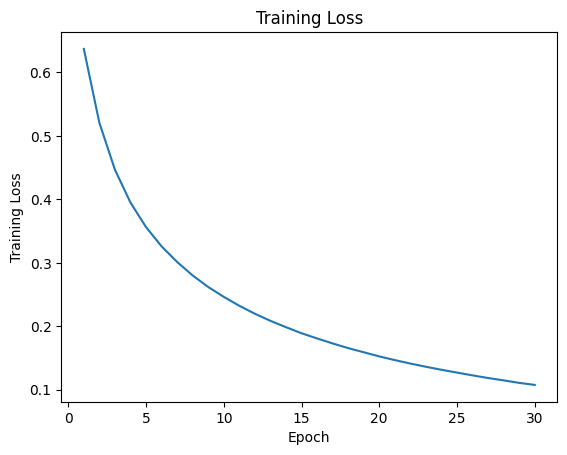

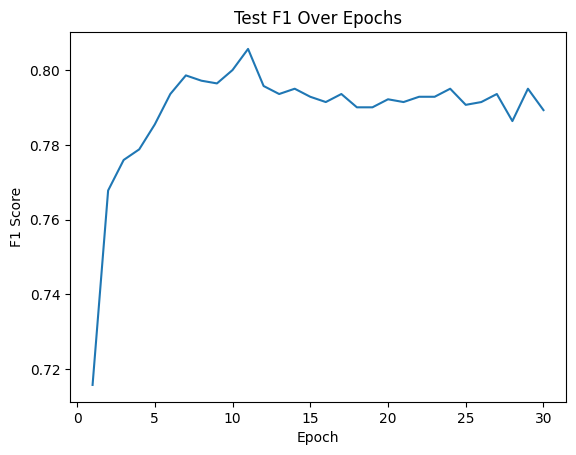

In [11]:
plt.figure()
plt.plot(history_df["epoch"], history_df["train_loss"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss")
plt.show()

plt.figure()
plt.plot(history_df["epoch"], history_df["f1"])
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Test F1 Over Epochs")
plt.show()

              precision    recall  f1-score   support

           0       0.82      0.81      0.82       321
           1       0.79      0.79      0.79       279

    accuracy                           0.80       600
   macro avg       0.80      0.80      0.80       600
weighted avg       0.80      0.80      0.80       600



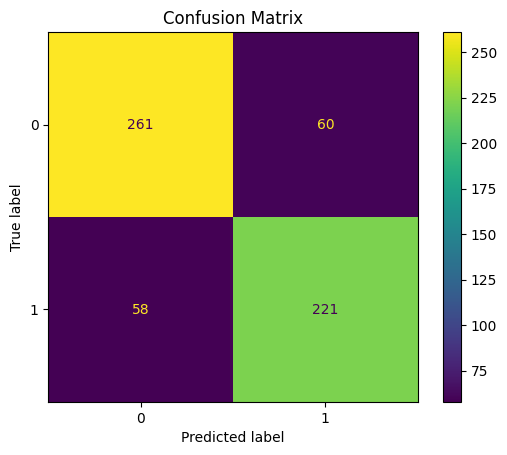

In [12]:
model.eval()

with torch.no_grad():
    test_logits = model(X_test_tensor)
    test_probs = torch.sigmoid(test_logits).numpy().ravel()
    test_preds = (test_probs >= CONFIG["threshold"]).astype(int)

print(classification_report(y_test, test_preds, zero_division=0))

cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [13]:
from sklearn.metrics import roc_auc_score, confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, test_preds).ravel()
metrics = {
    "accuracy": accuracy_score(y_test, test_preds),
    "f1": f1_score(y_test, test_preds, zero_division=0),
    "precision": precision_score(y_test, test_preds, zero_division=0),
    "recall": recall_score(y_test, test_preds, zero_division=0),
    "roc_auc": roc_auc_score(y_test, test_probs),  
    "true_positives": int(tp),
    "true_negatives": int(tn),
    "false_positives": int(fp),
    "false_negatives": int(fn),  
}

import datetime

metrics["experiment_name"] = CONFIG["experiment_name"]
metrics["timestamp"] = datetime.datetime.now().isoformat()
metrics["dataset_size"] = len(df)
metrics["train_size"] = len(X_train_text)
metrics["test_size"] = len(X_test_text)
metrics["positive_rate"] = float(y.mean())
metrics["epochs_trained"] = CONFIG["epochs"]
metrics["best_epoch"] = history_df.loc[history_df["f1"].idxmax(), "epoch"]

with open(OUTPUT_DIR / "tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

with open(OUTPUT_DIR / "config.json", "w") as f:
    json.dump(CONFIG, f, indent=4, default=str)

history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)

metrics = {
    "accuracy": accuracy_score(y_test, test_preds),
    "f1": f1_score(y_test, test_preds, zero_division=0),
    "precision": precision_score(y_test, test_preds, zero_division=0),
    "recall": recall_score(y_test, test_preds, zero_division=0),
}

with open(OUTPUT_DIR / "final_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("Saved to:", OUTPUT_DIR)
print(metrics)

Saved to: /kaggle/working/slp_tfidf_extremism_v1
{'accuracy': 0.8033333333333333, 'f1': 0.7892857142857143, 'precision': 0.7864768683274022, 'recall': 0.7921146953405018}


In [14]:
def run_experiment(config):
    set_seed(config["random_seed"])

    # Vectorize
    vectorizer = TfidfVectorizer(
        max_features=config["max_features"], ngram_range=config["ngram_range"],
        min_df=config["min_df"], max_df=config["max_df"],
        lowercase=True, stop_words="english"
    )
    X_train_vec = vectorizer.fit_transform(X_train_text)
    X_test_vec = vectorizer.transform(X_test_text)

    # Tensors
    X_train_tensor = torch.tensor(X_train_vec.toarray(), dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_vec.toarray(), dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor),
                              batch_size=config["batch_size"], shuffle=True)

    # Model
    model = SLPTextClassifier(X_train_tensor.shape[1])
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])

    # Train
    best_f1 = 0
    for epoch in range(config["epochs"]):
        model.train()
        total_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        model.eval()
        with torch.no_grad():
            test_probs = torch.sigmoid(model(X_test_tensor)).numpy().ravel()
            test_preds = (test_probs >= config["threshold"]).astype(int)
        f1 = f1_score(y_test, test_preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_preds = test_preds  # save preds at best epoch
            best_probs = test_probs

    # Final metrics
    return {
        "experiment_name": config["experiment_name"],
        "lr": config["lr"],
        "max_features": config["max_features"],
        "ngram_range": str(config["ngram_range"]),
        "weight_decay": config["weight_decay"],
        "batch_size": config["batch_size"],
        "best_f1": best_f1,
        "accuracy": accuracy_score(y_test, test_preds),
        "precision": precision_score(y_test, test_preds, zero_division=0),
        "recall": recall_score(y_test, test_preds, zero_division=0),
    }

In [15]:
import itertools

ablation_grid = {
    "lr":           [0.001, 0.0005, 0.0001],   # lower — 0.01 is clearly too high
    "weight_decay": [1e-3, 1e-4, 1e-5],         # add regularization, 0.0 is clearly too low
    "max_features": [10000, 20000, 50000],       # keep this range, reasonable
    "ngram_range":  [(1, 1), (1, 2), (1, 3)],   # keep, worth exploring
    "batch_size":   [32, 64],                    # drop 128, likely too large for your dataset
}

# Generate all combinations
keys = list(ablation_grid.keys())
combinations = list(itertools.product(*ablation_grid.values()))
print(f"Total experiments: {len(combinations)}")

Total experiments: 162


In [16]:
all_results = []

for i, combo in enumerate(combinations):
    config = {**CONFIG}  # start from your base config
    for k, v in zip(keys, combo):
        config[k] = v
    config["experiment_name"] = f"ablation_{i:04d}"
    
    print(f"\n[{i+1}/{len(combinations)}] Running: { {k: v for k, v in zip(keys, combo)} }")
    result = run_experiment(config)
    all_results.append(result)

results_df = pd.DataFrame(all_results).sort_values("best_f1", ascending=False)
results_df.to_csv("/kaggle/working/ablation_results.csv", index=False)
display(results_df.head(10))


[1/162] Running: {'lr': 0.001, 'weight_decay': 0.001, 'max_features': 10000, 'ngram_range': (1, 1), 'batch_size': 32}

[2/162] Running: {'lr': 0.001, 'weight_decay': 0.001, 'max_features': 10000, 'ngram_range': (1, 1), 'batch_size': 64}

[3/162] Running: {'lr': 0.001, 'weight_decay': 0.001, 'max_features': 10000, 'ngram_range': (1, 2), 'batch_size': 32}

[4/162] Running: {'lr': 0.001, 'weight_decay': 0.001, 'max_features': 10000, 'ngram_range': (1, 2), 'batch_size': 64}

[5/162] Running: {'lr': 0.001, 'weight_decay': 0.001, 'max_features': 10000, 'ngram_range': (1, 3), 'batch_size': 32}

[6/162] Running: {'lr': 0.001, 'weight_decay': 0.001, 'max_features': 10000, 'ngram_range': (1, 3), 'batch_size': 64}

[7/162] Running: {'lr': 0.001, 'weight_decay': 0.001, 'max_features': 20000, 'ngram_range': (1, 1), 'batch_size': 32}

[8/162] Running: {'lr': 0.001, 'weight_decay': 0.001, 'max_features': 20000, 'ngram_range': (1, 1), 'batch_size': 64}

[9/162] Running: {'lr': 0.001, 'weight_decay': 

,experiment_name,lr,max_features,ngram_range,weight_decay,batch_size,best_f1,accuracy,precision,recall
22,ablation_0022,0.001,10000,"(1, 3)",0.00010,32,0.783088,0.800000,0.797753,0.763441
28,ablation_0028,0.001,20000,"(1, 3)",0.00010,32,0.783088,0.800000,0.797753,0.763441
34,ablation_0034,0.001,50000,"(1, 3)",0.00010,32,0.783088,0.800000,0.797753,0.763441
50,ablation_0050,0.001,50000,"(1, 2)",0.00001,32,0.782450,0.801667,0.798507,0.767025
38,ablation_0038,0.001,10000,"(1, 2)",0.00001,32,0.782450,0.801667,0.798507,0.767025
44,ablation_0044,0.001,20000,"(1, 2)",0.00001,32,0.782450,0.801667,0.798507,0.767025
16,ablation_0016,0.001,50000,"(1, 3)",0.00100,32,0.780488,0.801667,0.812500,0.745520
10,ablation_0010,0.001,20000,"(1, 3)",0.00100,32,0.780488,0.801667,0.812500,0.745520
4,ablation_0004,0.001,10000,"(1, 3)",0.00100,32,0.780488,0.801667,0.812500,0.745520
46,ablation_0046,0.001,20000,"(1, 3)",0.00001,32,0.780220,0.798333,0.794776,0.763441
